# Tarea Semanal 1
    la amplitud máxima de la senoidal (volts)
    su valor medio (volts)
    la frecuencia (Hz)
    la fase (radianes)
    la cantidad de muestras digitalizada por el ADC (# muestras)
    la frecuencia de muestreo del ADC.

es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

In [2]:

def undB (dB):
    return 10**(dB/10)

def dB (x):
    return 10*np.log10(x)

In [3]:
fs = 1000       #500Hz de BW
ts = 1/fs
N = fs          #DeltaF = 1Hz; norm
df = fs/N
dt = 1/df

In [4]:
vmax = 1.        
dc = 0.          
ff = 5
ph = 0

snr_xr = 30

In [5]:
def miNoise (Pot, nn):
    xna = np.random.normal(loc = 0, scale = np.sqrt(Pot), size = N) 
    return xna

def miSin (vmax, dc, ff, ph, nn, fs):
    tt = np.arange(N) * 1/fs
    xx = dc + vmax * np.sin( 2 * np.pi * ff * tt + ph)
    return (tt, xx)

def miSaw (vmax, dc, ff, ph, nn, fs):
    tt = np.arange(N) * 1/fs
    To = 1/ff
    delay = To * ph/(2*np.pi)
    ####
    xx =  dc - (vmax / 2) + vmax * ((tt + delay)% To) * ff
    return (tt, xx)


def miTri (vmax, dc, ff, ph, nn, fs):
    tt = np.arange(N) * 1/fs
    To = 1/ff
    delay = To * ph/(2*np.pi)
    ####    
    xx =  2 * vmax * ((tt + delay)% To) * ff
    for i in range(len(tt)):    
        if (0.5 <= ff*((tt[i] + To * ph/(2*np.pi)) % To)):
            xx[i] =  2 * vmax - xx[i]
    xx = xx + dc - (vmax/4)
    return (tt, xx)
    
def miPWM (vmax, dc, ff, ph, nn, fs, duty):
    tt = np.arange(N) * 1/fs
    ####    
    xx = np.arange(N)
    for i in range(len(tt)):
        if (duty < ((tt[i]*ff + ph/(2*np.pi)) % 1)):
            xx[i] = vmax
        else:
            xx[i] = 0
    xx = xx + dc - (vmax * duty)

def miSignalGenerator (sigType = "sine", vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs, snr = -1, duty = 0.5):
    match sigType:
        case "sine":
            tt, xx = miSin(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs)
        case "saw":
            tt, xx = miSaw(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs)
        case "revSaw":
            tt, xx = miSaw(vmax = -vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs)
        case "tri":
            tt, xx = miTri(vmax = -vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs)
        case "PWM":
            tt, xx = miPWM(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = duty)
        case "square":
            tt, xx = miPWM(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = 0.5)
        case _:
            print("sigType invlaido")
            tt = np.arange(N)
            xx = np.arange(N)
    
    if (snr != -1):
        Px = vmax**2/2
        Pna = Px / undB(snr)
        xx = xx + miNoise(Pot = Pna, nn = nn)
    return (tt, xx)

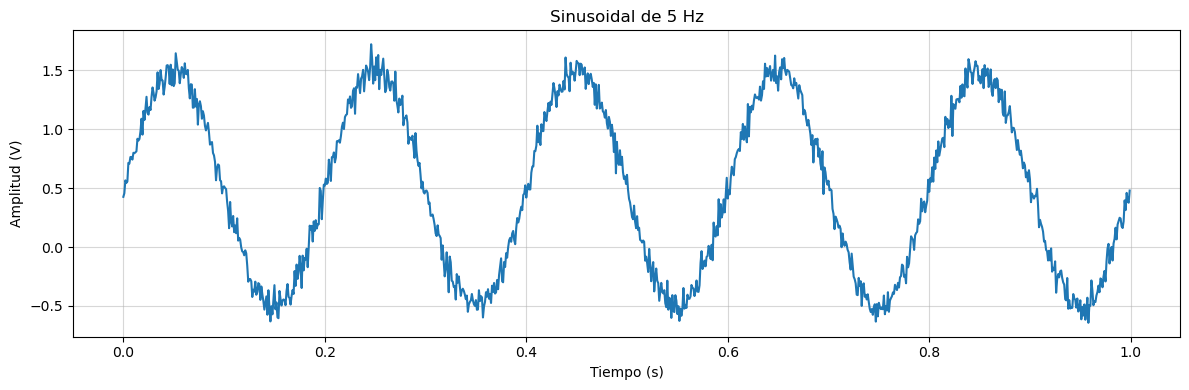

In [6]:
tt, xx = miSignalGenerator(dc = 0.5, snr = 20)

plt.figure(1, figsize = (12,4))
plt.clf()
           
plt.plot(tt,xx, linewidth=1.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(linestyle='-', alpha=0.5)
plt.title(f'Sinusoidal de {ff} Hz')
plt.tight_layout()
plt.show()

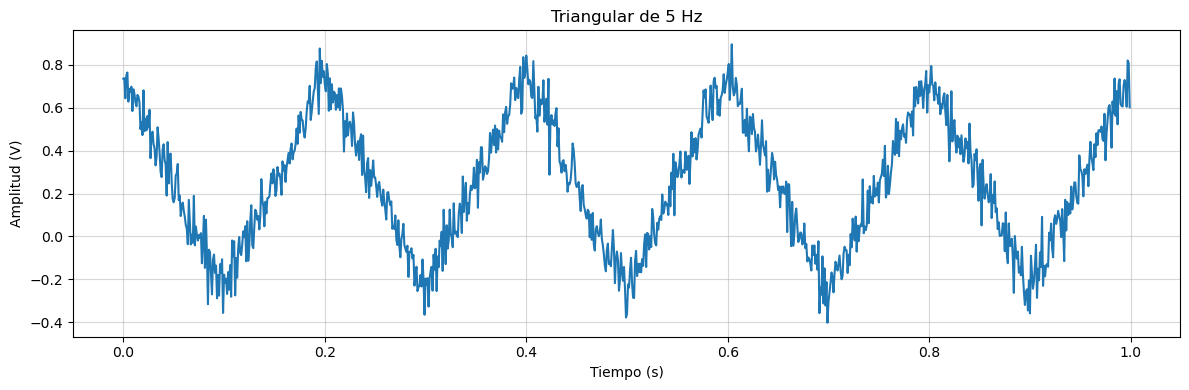

In [7]:
tt2, xx2 = miSignalGenerator("tri", dc = 0.5, snr = 20)

plt.figure(2, figsize = (12,4))
plt.clf()
           
plt.plot(tt2,xx2, linewidth=1.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(linestyle='-', alpha=0.5)
plt.title(f'Triangular de {ff} Hz')
plt.tight_layout()
plt.show()